In [4]:
a=Value(3.0); a.label='a'
b=Value(3.0); b.label='b'
c=a+b; c.label='c'
d=Value(4.0); d.label='d'
e=Value(5.0, label='e'); 
f=d*e; f.label='f'
g=c*f; g.label='g'


In [7]:
g.backward()

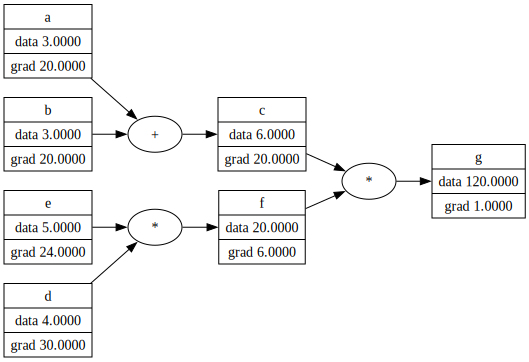

In [8]:
draw_dot(g)

In [9]:
x1=torch.Tensor([2.0]).double()       ; x1.requires_grad=True
x2=torch.Tensor([0.0]).double()       ; x2.requires_grad=True
w1=torch.Tensor([-3.0]).double()      ; w1.requires_grad=True
w2=torch.Tensor([1.0]).double()       ; w2.requires_grad=True
b=torch.Tensor([6.8813]).double()
n=x1*w1 + x2*w2 + b
o=torch.tanh(n)

o.backward()
print(x2.grad.item())
print(w2.grad.item())
print(x1.grad.item())
print(w1.grad.item())

0.5000520546564731
0.0
-1.5001561639694192
1.0001041093129461


In [2]:
import math
import random
import torch
import time
import matplotlib.pyplot as plt

In [19]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data=data
        self.grad=0.0
        self._backward= lambda: None
        self._prev=set(_children)
        self._op=_op
        self.label=label
        
    def __repr__(self):
        return f"Value(data = {self.data})"
        
    def __add__(self, other):
        other=other if isinstance (other, Value) else Value(other)
        out=Value(self.data+other.data, (self, other),'+')

        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad
        out._backward=_backward
        
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def __neg__(self): 
        return self * -1

    def __sub__(self, other):
        return self+(-other)
    
    def __mul__(self, other):
        other=other if isinstance (other, Value) else Value(other)
        out=Value(self.data*other.data, (self, other),'*')
        
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        
        return out
    
    def __radd__(self, other): # other + self
        return self + other
    
    def __rmul__(self, other):
        return self*other

    def backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad=1.0

        for node in reversed(topo):
            node._backward()

    #Activation Functions
    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t, (self,), 'tanh')

        def _backward():
            self.grad+=(1-t**2)*out.grad
        out._backward=_backward

        return out

    def sigmoid(self):
        x=self.data
        sig=1/(1+(math.exp(-x)))
        out=Value(sig, (self,), 'sigmoid')

        def _backward():
            self.grad+=(sig*(1-sig))*out.grad
        out._backward=_backward

        return out

    def leakyReLU(self):
        out=Value(0.01*x if self.data<=0 else self.data, (self,), 'leaky ReLU')

        def _backward():
            self.grad+=(0.01 if self.data<0 else 1)*out.grad
        out._backward=_backward

        return out
    
    def ReLU(self):
        out=Value(0 if self.data<=0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad+=(self.data>0)*out.grad
        out._backward=_backward

        return out

In [61]:
def trace(root):
    nodes, edges=set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

In [62]:
#Graphviz API
from graphviz import Digraph
def draw_dot(root):
    dot=Digraph(format='svg', graph_attr={'rankdir':'LR'})
    nodes, edges=trace(root)

    for n in nodes:
        uid=str(id(n))
        dot.node(name=uid, label="%s | {data %.4f} | {grad %.4f}" % (n.label, n.data, n.grad), shape='record')

        
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid+n._op, uid)
        

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)
    return dot

In [63]:
#Copied Code beyond this point: 
class Neuron:
    def __init__(self, nin):
        self.w=[Value(random.uniform(-1,1), label=f'w{i}') for i in range(nin)] 
        self.b=Value(random.uniform(-1,1), label='b')

    def __call__(self, x):
        #w*x+b
        act=sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        #out=act.ReLU()
        out=act
        return out

    def parameters(self):
        return self.w+[self.b]
class Layer:
    def __init__(self, nin, nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs=[n(x) for n in self.neurons]
        #return outs[0] if len(outs)==1 else outs
        return outs

    def parameters(self):
        params=[]
        for neuron in self.neurons:
            ps=neuron.parameters()
            params.extend(ps)
        return params
class MLP: 
    def __init__(self, nin, nouts):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i], sz[i+1]) for i in range(len(nouts))] #calls Layer.__init__
    def __call__(self, x):
        for i,layer in enumerate(self.layers):
            x=layer(x) #calls Layer.__call__
            
            if i!=len(self.layers)-1:
                x=[v.ReLU() for v in x]
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [64]:
x=[2.0, 3.0, -1.0]
#n=Layer(2,3)
#n(x)

n=MLP(3, [4,4,1]) #3 inputs, 2 layers of 4 neurons each[4,4], 1 output neuron
#draw_dot(n(x))

In [65]:
n=MLP(3, [4,4,1]) #3 inputs, 2 layers of 4 neurons each[4,4], 1 output neuron

xs=[
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1,0],
]
ys=[1.0, 1.0, 1.0, 1.0]

In [66]:
def loss_plot(losses):
    plt.plot(losses)
    plt.show

In [71]:
#Training loop
def train(epoch, xs, ys, n):
    losses=[]
    epoch_timings=[]
    for k in range(epoch):
        start=time.time()
        
        #forward pass
        ypred=[n(x) for x in xs]
        loss=sum((yout[0]-ygt)**2 for ygt, yout in zip(ys, ypred))
        losses.append(loss.data)
        
        #backward pass
        for p in n.parameters():
            p.grad=0.0 #zero_grad()
        loss.backward()
    
        #update
        for p in n.parameters():
            p.data+=-0.01 * p.grad
        end=time.time()

        duration=end-start
        epoch_timings.append(duration)
        print(f"Epoch: {k} | Loss: {loss.data} | Duration: {duration: .4f}s")
    
    loss_plot(losses)
    print(ypred)
    return loss, ypred

Epoch: 0 | Loss: 9.251544526612304e-05 | Duration:  0.0030s
Epoch: 1 | Loss: 9.184747333883891e-05 | Duration:  0.0051s
Epoch: 2 | Loss: 9.118635315168954e-05 | Duration:  0.0026s
Epoch: 3 | Loss: 9.053163001613902e-05 | Duration:  0.0020s
Epoch: 4 | Loss: 8.988294975248767e-05 | Duration:  0.0020s
Epoch: 5 | Loss: 8.924003388816776e-05 | Duration:  0.0050s
Epoch: 6 | Loss: 8.860266117885425e-05 | Duration:  0.0020s
Epoch: 7 | Loss: 8.797065373345866e-05 | Duration:  0.0015s
Epoch: 8 | Loss: 8.734386655433093e-05 | Duration:  0.0020s
Epoch: 9 | Loss: 8.672217963579326e-05 | Duration:  0.0065s
Epoch: 10 | Loss: 8.610549198904773e-05 | Duration:  0.0015s
Epoch: 11 | Loss: 8.549371712113892e-05 | Duration:  0.0020s
Epoch: 12 | Loss: 8.488677961309946e-05 | Duration:  0.0021s
Epoch: 13 | Loss: 8.428461252932516e-05 | Duration:  0.0056s
Epoch: 14 | Loss: 8.368715545601992e-05 | Duration:  0.0020s
Epoch: 15 | Loss: 8.309435301555456e-05 | Duration:  0.0030s
Epoch: 16 | Loss: 8.25061537410555

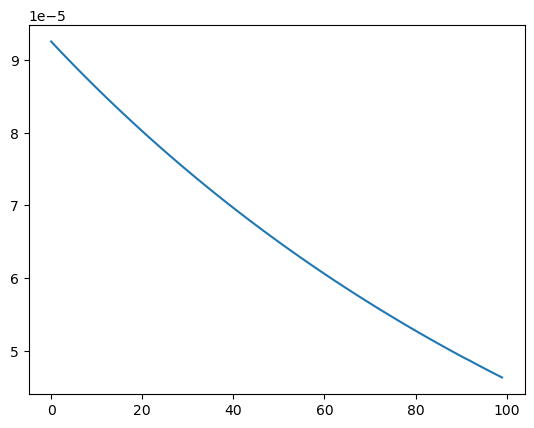

In [72]:
final_loss, ypred=train(100, xs, ys, n)

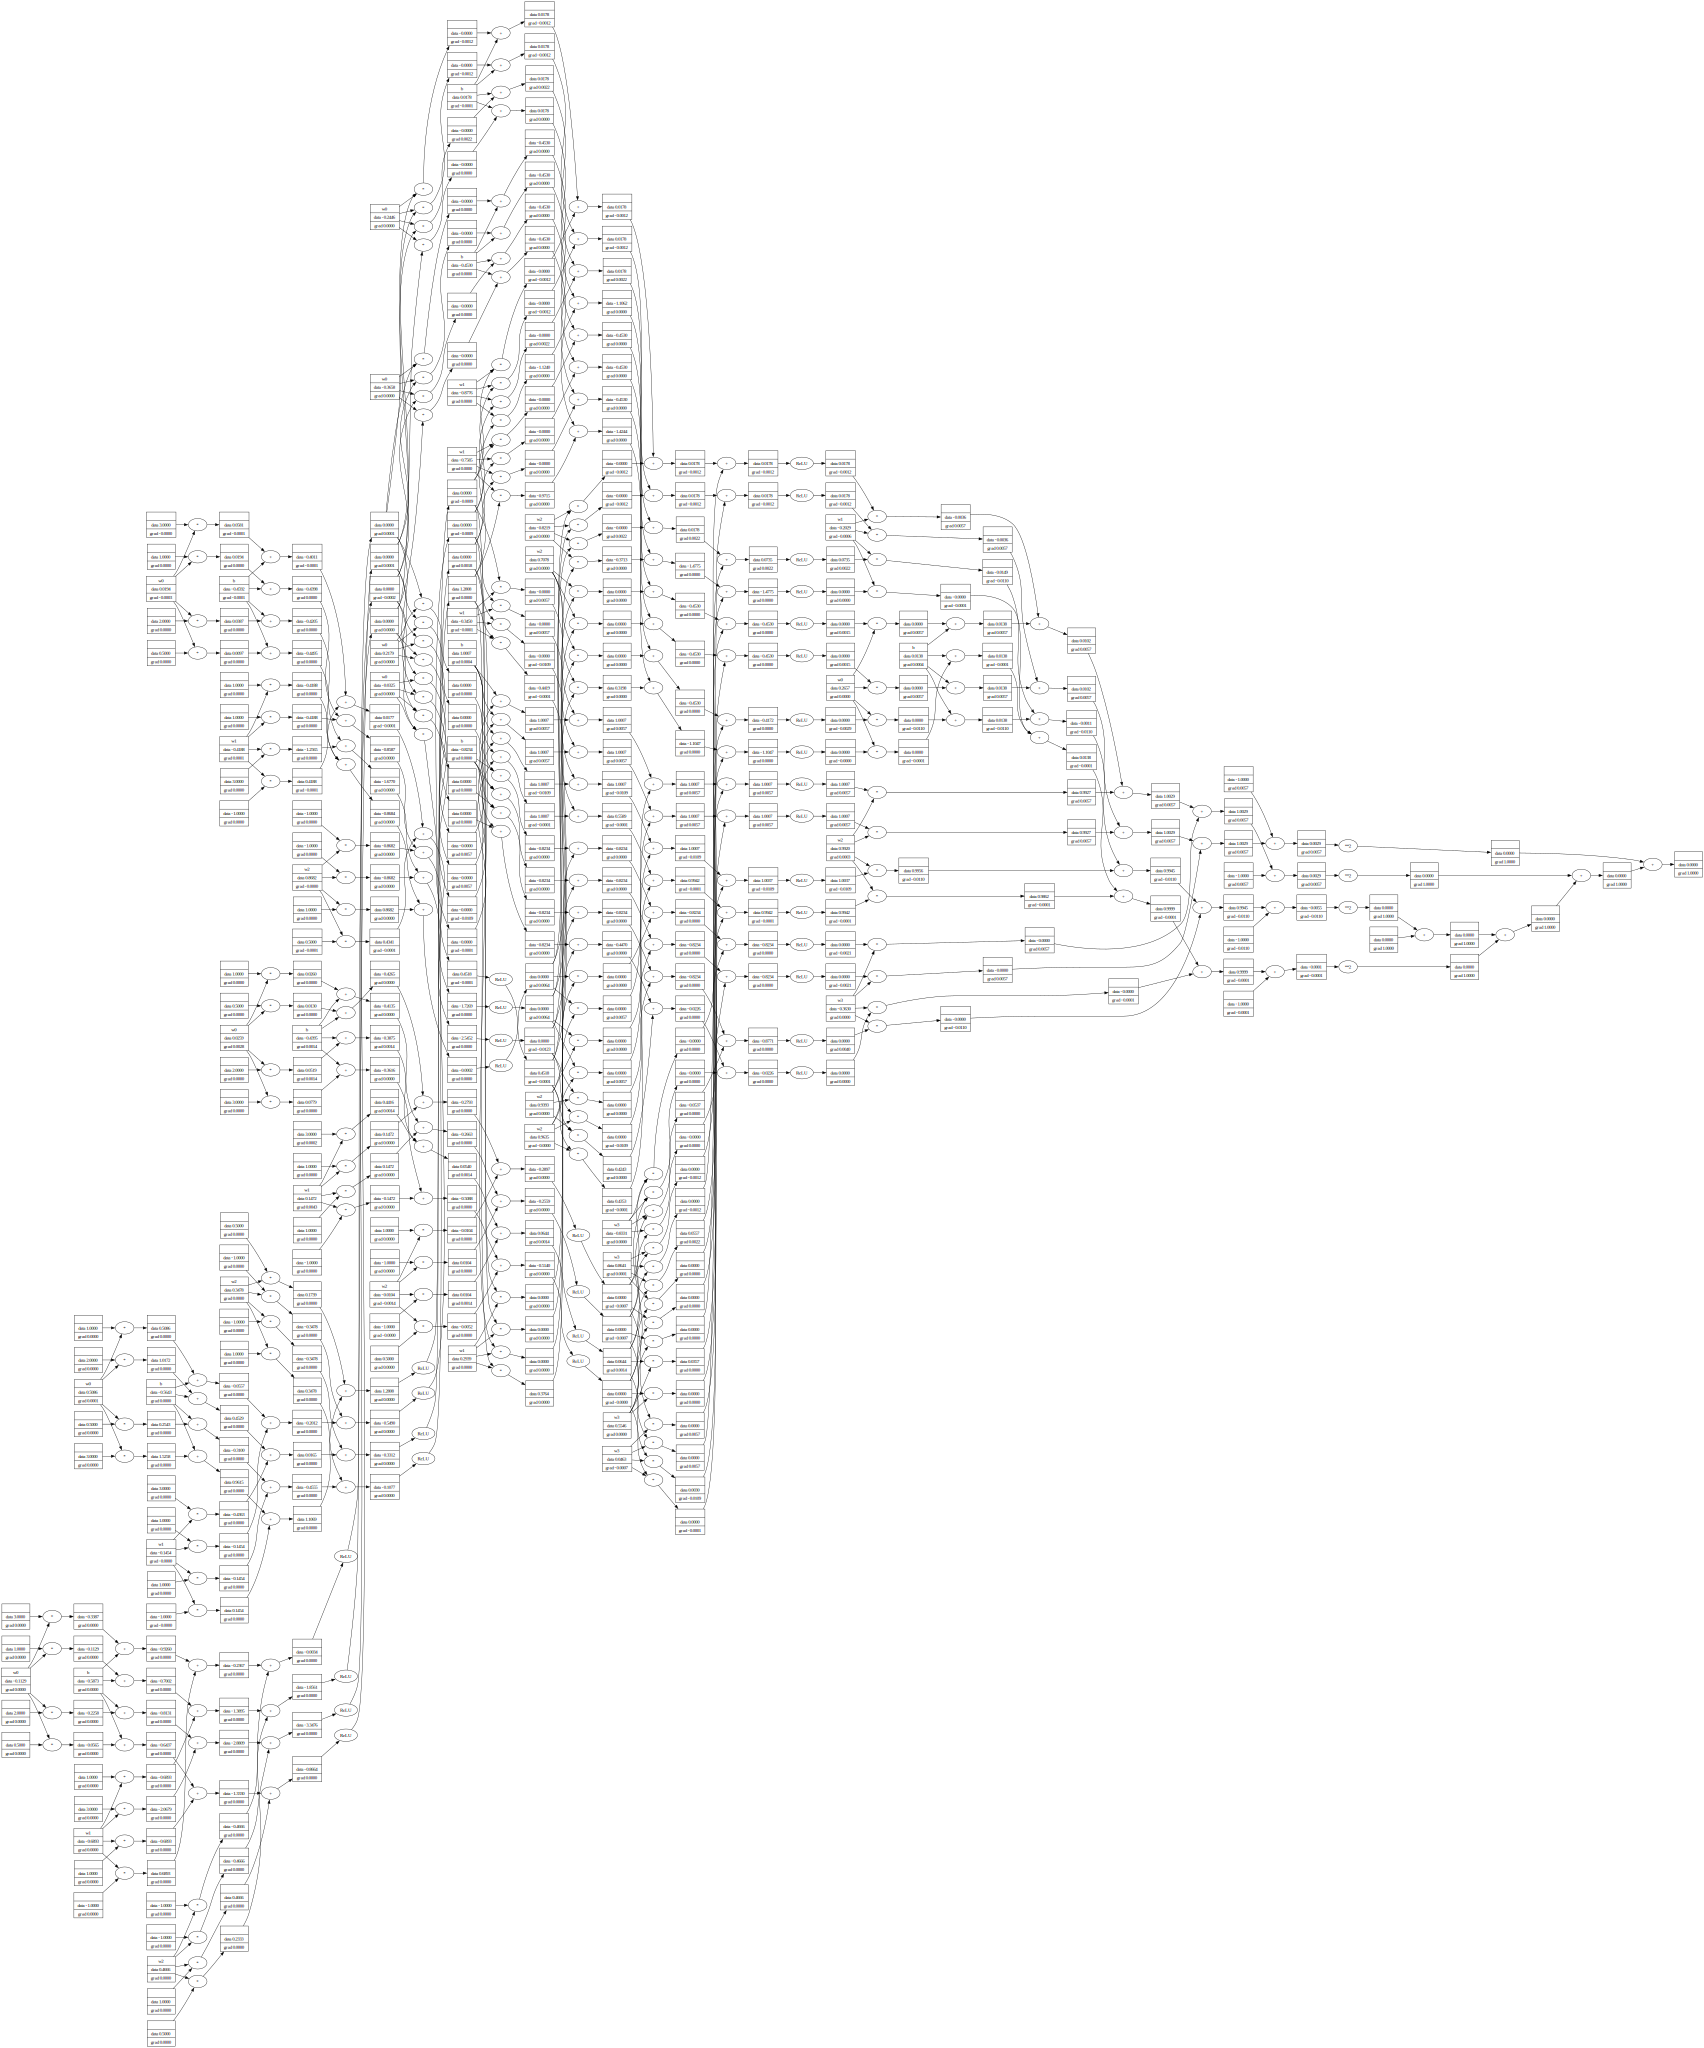

In [73]:
draw_dot(final_loss)

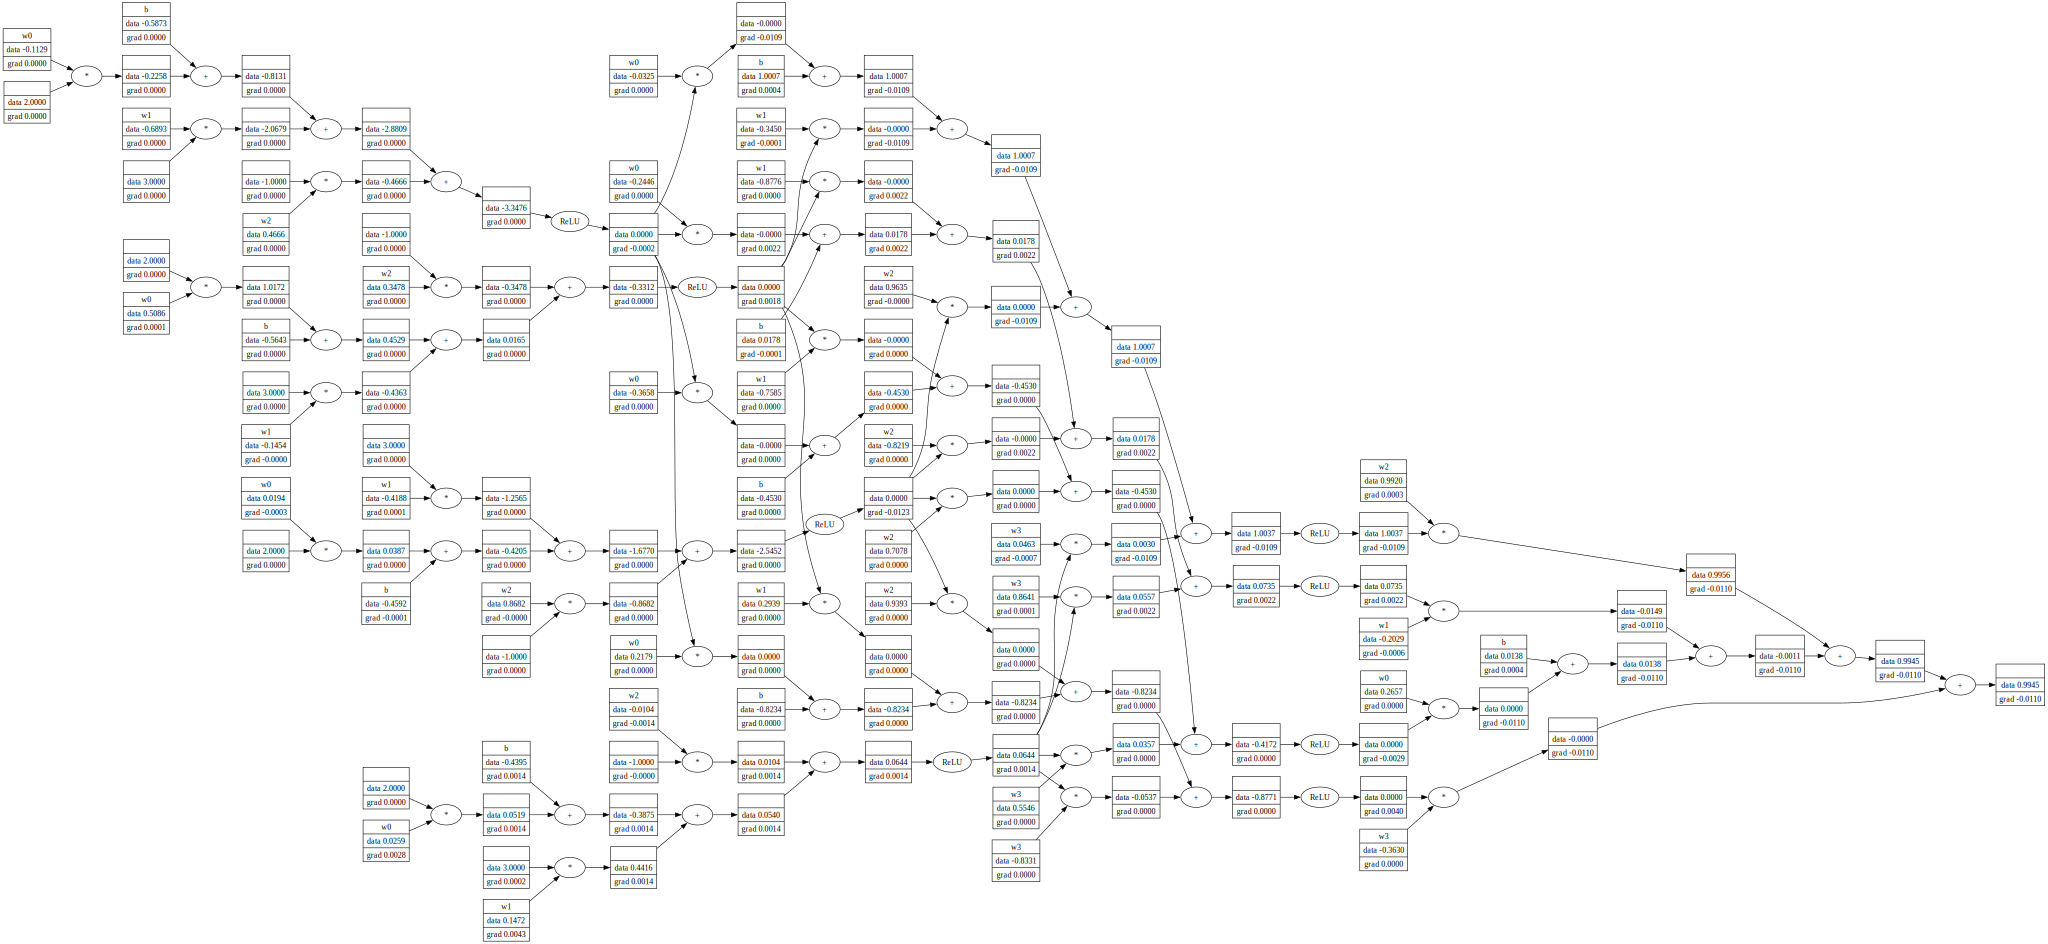

In [74]:
draw_dot(ypred[0][0])